Aggregation Model

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from types import SimpleNamespace
from datetime import datetime

## import data from particle concentration, backscatter, fluorescence
part_conc_490 = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="4903659_binned_small_removed").iloc[:, 1:]
part_conc_699 = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="6990636_binned_small_removed").iloc[:, 1:]

bbp_490 = pd.read_excel("BBP_binned.xlsx", sheet_name="4903659", index_col=0)
bbp_699 = pd.read_excel("BBP_binned.xlsx", sheet_name="6990636")

chla_fluor_490 = pd.read_excel("Chl_fluor_binned.xlsx", sheet_name="4903659")
chla_fluor_699 = pd.read_excel("Chl_fluor_binned.xlsx", sheet_name="6990636")

# define depth array, time array (profiles)
depth = part_conc_490["depth_bin"].iloc[:60]
time_490 = pd.Series(range(1, 45))
time_699 = pd.Series(range(1, 78))      # please change this as I've converted to proper date time later down the script and this is now redundant



In [3]:
## separating float 4903659 profiles into individual UVP6 dataframes through dot notation
# this does not contain backscatter or fluorescence yet

# Create container object
f490 = SimpleNamespace()

# Identify blank rows (all NaN) and get indices
blank_rows = part_conc_490.isna().all(axis=1)
split_points = blank_rows[blank_rows].index.tolist()

# Add start and end boundaries
split_points = [-1] + split_points + [len(part_conc_490)]

skip_numbers = {13, 19}

section_number = 1

for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]

    # Extract the block
    block = part_conc_490.iloc[start:end].reset_index(drop=True)

    #block["bbp"] = bbp_490.iloc[:len(block), section_number - 1].values
    #block["chla"] = chla_fluor_490.iloc[:len(block), section_number - 1].values

# Skip truly empty blocks
    if len(block) == 0:
        continue
    
# Skip numbers before assigning
    while section_number in skip_numbers:
        section_number += 1

    attr_name = f"p{section_number}"
    setattr(f490, attr_name, block)

    section_number += 1


#print([attr for attr in dir(f490) if attr.startswith("p")])

# Export an individual profile here (in case one needs checking!)
#f490.p7.to_excel("f490.p7.xlsx", index=False)




## tada, doing the same with 6990636 
# this does not contain backscatter or fluorescence yet

# Create container object
f699 = SimpleNamespace()

# Identify blank rows (all NaN) and get indices
blank_rows = part_conc_699.isna().all(axis=1)
split_points = blank_rows[blank_rows].index.tolist()

# Add start and end boundaries
split_points = [-1] + split_points + [len(part_conc_699)]

skip_numbers = {4, 17, 29, 53, 72}   # works too 11/6

section_number = 1

for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]

    # Extract the block
    block = part_conc_699.iloc[start:end].reset_index(drop=True)

    #block["bbp"] = bbp_490.iloc[:len(block), section_number - 1].values
    #block["chla"] = chla_fluor_490.iloc[:len(block), section_number - 1].values

# Skip truly empty blocks
    if len(block) == 0:
        continue
    
# Skip numbers before assigning
    while section_number in skip_numbers:
        section_number += 1

    attr_name = f"p{section_number}"
    setattr(f699, attr_name, block)

    section_number += 1

# Export an individual profile here (in case one needs checking!)
f699.p8.to_excel("f699.p8.xlsx", index=False)


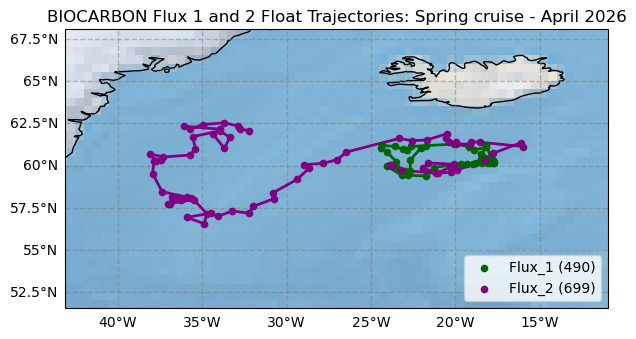

In [16]:
## Creating Figures for Presentation
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Argo float trajectories figure

float_data = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="UVP_Float_Data")
lat = float_data.loc[:,"latitude"]
lon = float_data.loc[:,"longitude"]
lat.drop_duplicates(inplace = True), lon.drop_duplicates(inplace = True)

# index of first value of 699 is 44
lat_490 = lat[:44]
lon_490 = lon[:44]
lat_699 = lat[44:]
lon_699 = lon[44:]

# plotting on map

# Create a figure with a map projection
fig = plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.OCEAN) #facecolor='lightblue')
ax.stock_img()

gl = ax.gridlines(draw_labels=True,
                  linewidth=1,
                  color='gray',
                  alpha=0.5,
                  linestyle='--')

gl.top_labels = False
gl.right_labels = False

s1_lat = 60.00016, s1_lon = -24.0004
s2_lat = 60.01922, s2_lon = -23.7194 
s3_lat = 59.43715, s3_lon = -22.6379 
s4_lat = 59.30469, s4_lon = -21.9108 
s5_lat = 60.26593, s5_lon = -21.0875

r1_lat = 56.21604, r1_lon = -26.8302
r2_lat = 57.12564, r2_lon = -26.1376
r3_lat = 57.23220, r3_lon = -28.3443
r4_lat = 59.01343, r4_lon = -24.6674 
r5_lat = 60.12009, r5_lon = -18.9309


# Plot the points
ax.scatter(lon_490, lat_490, color='darkgreen', s=20, label="Flux_1 (490)", transform=ccrs.PlateCarree(), zorder=5)
ax.scatter(lon_699, lat_699, color='purple', s=20, label="Flux_2 (699)", transform=ccrs.PlateCarree(), zorder=5)
ax.scatter(s1_lon, s1_lat, color='black', s=50, label="S1", transform=ccrs.PlateCarree())

# Draw lines connecting points
ax.plot(lon_490, lat_490, color='darkgreen', linewidth=2, transform=ccrs.PlateCarree())
ax.plot(lon_699, lat_699, color='purple', linewidth=2, transform=ccrs.PlateCarree())

# Set extent (optional: zoom to data)
ax.set_extent([
    lon.min(), lon.max(),
    lat.min(), lat.max()
])

ax.legend(loc='lower right')

plt.title("BIOCARBON Flux 1 and 2 Float Trajectories: Spring cruise - April 2026")
plt.show()
                        


C:\Users\steph\AppData\Local\Temp\ipykernel_26524\786448112.py:11: SettingWithCopyWarning: modifications to a property of a datetimelike object are not supported and are discarded. Change values on the original.
  time.drop_duplicates(inplace = True)


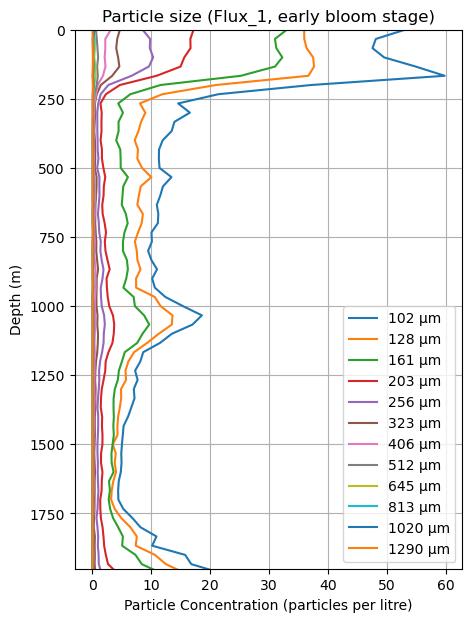

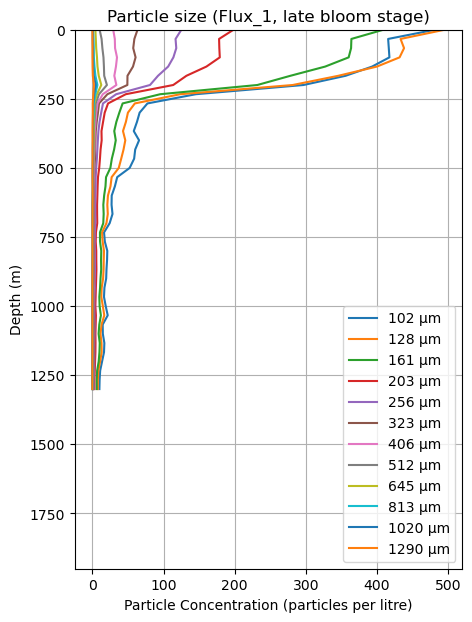

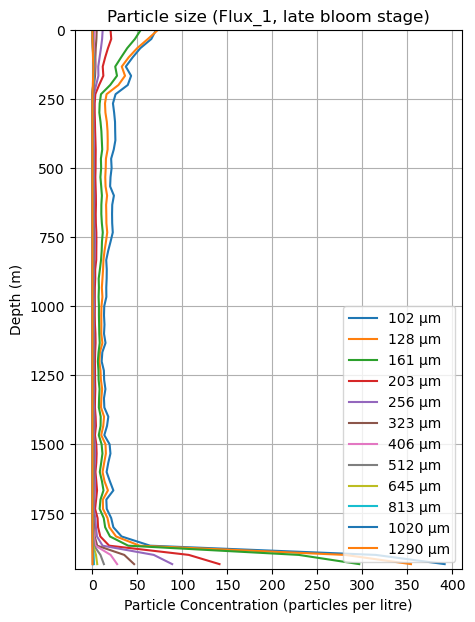

In [79]:
# Code for producing final figure - kill it with fire

# Convert time into dates
epoch_time = float_data.loc[:,"epoch_time"]
time = pd.to_datetime(
    epoch_time,
    unit="s",
    utc=True
).dt.date

time.drop_duplicates(inplace = True)
#print(time.iloc[[12, 18, 27, 28]])
time_subset = time.iloc[:44]
time_490 = time_subset.drop(time_subset.index[[12, 18, 27, 28]])    # excluding certain time values due to backscatter infrequent sampling

"""""
#print(time_490.shape)
#print(depth.shape)
#print(bbp_490.shape)
x = np.arange(1, 41, 1)

# Plotting particle concentration data with time for 490
fig, ax = plt.subplots(figsize=(8,6))
contour = ax.contour(x, depth, bbp_490, cmap="viridis")
fig.colorbar(contour)
ax.set_xlabel("Days")
ax.set_ylabel("Depth")
ax.set_title("Backscatter coefficient over time and depth")
ax.grid(True)
plt.show()

"""""

# Attempt 2, depth plot

fig, ax = plt.subplots(figsize=(5, 7))
depth_p2 = np.arange(0, 2000, (2000/60))

# Plot profile
ax.plot(f490.p2[102], depth_p2, label="102 μm", linestyle='-')
ax.plot(f490.p2[128], depth_p2, label="128 μm", linestyle='-')
ax.plot(f490.p2[161], depth_p2, label="161 μm", linestyle='-')
ax.plot(f490.p2[203], depth_p2, label="203 μm", linestyle='-')
ax.plot(f490.p2[256], depth_p2, label="256 μm", linestyle='-')
ax.plot(f490.p2[323], depth_p2, label="323 μm", linestyle='-')
ax.plot(f490.p2[406], depth_p2, label="406 μm", linestyle='-')
ax.plot(f490.p2[512], depth_p2, label="512 μm", linestyle='-')
ax.plot(f490.p2[645], depth_p2, label="645 μm", linestyle='-')
ax.plot(f490.p2[813], depth_p2, label="813 μm", linestyle='-')
ax.plot(f490.p2[1020], depth_p2, label="1020 μm", linestyle='-')
ax.plot(f490.p2[1290], depth_p2, label="1290 μm", linestyle='-')
#ax.plot(f490.p2[1630], depth_p2, marker='o', linestyle='-')
#ax.plot(f490.p2[2050], depth_p2, marker='o', linestyle='-')

# Labels and title
ax.set_xlabel("Particle Concentration (particles per litre)")
ax.set_ylabel("Depth (m)")
ax.set_title("Particle size (Flux_1, early bloom stage)")
ax.margins(y=0)
ax.set_ylim(0, 1950)
ax.legend(loc="lower right")

# Invert y-axis (important for depth plots ✅)
ax.invert_yaxis()

# Optional grid
ax.grid(True)

plt.show()



# Attempt 2, depth plot

fig, ax = plt.subplots(figsize=(5, 7))
depth_p2 = np.arange(0, 2000, (2000/60))

# Plot profile
ax.plot(f490.p21[102], depth_p2, label="102 μm", linestyle='-')
ax.plot(f490.p21[128], depth_p2, label="128 μm", linestyle='-')
ax.plot(f490.p21[161], depth_p2, label="161 μm", linestyle='-')
ax.plot(f490.p21[203], depth_p2, label="203 μm", linestyle='-')
ax.plot(f490.p21[256], depth_p2, label="256 μm", linestyle='-')
ax.plot(f490.p21[323], depth_p2, label="323 μm", linestyle='-')
ax.plot(f490.p21[406], depth_p2, label="406 μm", linestyle='-')
ax.plot(f490.p21[512], depth_p2, label="512 μm", linestyle='-')
ax.plot(f490.p21[645], depth_p2, label="645 μm", linestyle='-')
ax.plot(f490.p21[813], depth_p2, label="813 μm", linestyle='-')
ax.plot(f490.p21[1020], depth_p2, label="1020 μm", linestyle='-')
ax.plot(f490.p21[1290], depth_p2, label="1290 μm", linestyle='-')
#ax.plot(f490.p2[1630], depth_p2, marker='o', linestyle='-')
#ax.plot(f490.p2[2050], depth_p2, marker='o', linestyle='-')

# Labels and title
ax.set_xlabel("Particle Concentration (particles per litre)")
ax.set_ylabel("Depth (m)")
ax.set_title("Particle size (Flux_1, late bloom stage)")
ax.margins(y=0)
ax.set_ylim(0, 1950)
ax.legend(loc="lower right")

# Invert y-axis (important for depth plots ✅)
ax.invert_yaxis()

# Optional grid
ax.grid(True)

plt.show()





# Attempt 2, depth plot

fig, ax = plt.subplots(figsize=(5, 7))
depth_p2 = np.arange(0, 2000, (2000/60))

# Plot profile
ax.plot(f490.p31[102], depth_p2, label="102 μm", linestyle='-')
ax.plot(f490.p31[128], depth_p2, label="128 μm", linestyle='-')
ax.plot(f490.p31[161], depth_p2, label="161 μm", linestyle='-')
ax.plot(f490.p31[203], depth_p2, label="203 μm", linestyle='-')
ax.plot(f490.p31[256], depth_p2, label="256 μm", linestyle='-')
ax.plot(f490.p31[323], depth_p2, label="323 μm", linestyle='-')
ax.plot(f490.p31[406], depth_p2, label="406 μm", linestyle='-')
ax.plot(f490.p31[512], depth_p2, label="512 μm", linestyle='-')
ax.plot(f490.p31[645], depth_p2, label="645 μm", linestyle='-')
ax.plot(f490.p31[813], depth_p2, label="813 μm", linestyle='-')
ax.plot(f490.p31[1020], depth_p2, label="1020 μm", linestyle='-')
ax.plot(f490.p31[1290], depth_p2, label="1290 μm", linestyle='-')
#ax.plot(f490.p2[1630], depth_p2, marker='o', linestyle='-')
#ax.plot(f490.p2[2050], depth_p2, marker='o', linestyle='-')

# Labels and title
ax.set_xlabel("Particle Concentration (particles per litre)")
ax.set_ylabel("Depth (m)")
ax.set_title("Particle size (Flux_1, late bloom stage)")
ax.margins(y=0)
ax.set_ylim(0, 1950)
ax.legend(loc="lower right")

# Invert y-axis (important for depth plots ✅)
ax.invert_yaxis()

# Optional grid
ax.grid(True)

plt.show()


In [ ]:
# define parameters of particle size class, fluor, backscatter (maybe do a backscatter POC relationship curve conversion?), eventually turbulence


# input equations for particle dynamics - two size class approach?